## DigitSort — Clustering Handwritten Digits Without Labels

### The Scenario

You've been hired by DigitSort, a document digitisation company that processes millions of scanned forms per day.  
A large batch of handwritten digit images has arrived — but nobody labelled them.  
Your task: automatically group similar-looking digits together so that human reviewers only need to verify one representative per group.

You have no labels to train on — only raw pixels.  
This is the core challenge of **unsupervised learning**: find structure when no one has told you what the structure is.

True labels are provided only for **evaluation** — not for training.

📖 **Background Reading — Start Here:**
- [K-Means Clustering — StatQuest (Video)](https://www.youtube.com/watch?v=4b5d3muPQmA)
- [Gaussian Mixture Models Explained — Towards Data Science](https://towardsdatascience.com/gaussian-mixture-models-explained-6986aaf5a95/)
- [EM Algorithm for GMM — StatQuest (Video)](https://www.youtube.com/watch?v=REypj2sy_5U)
- [ARI and NMI — Sklearn Clustering Evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)
- [Interactive K-Means Visualiser](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)
- [GMM Covariance Types Demo — Sklearn](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_covariances.html)

---

### Dataset
**sklearn Digits Dataset** — 8×8 grayscale images of handwritten digits 0–9.

| Property | Value |
|---|---|
| Samples | 1,797 |
| Raw feature space | 64 dimensions (8×8 pixels) |
| Classes | 10 (digits 0–9) |
| Labels available? | Yes — but **only for evaluation**, not training |

---

| Part | Topic |
|---|---|
| A | Data Exploration |
| B | k-Means Clustering |
| C | Cluster Confusion Analysis |
| D | Evaluation Metrics (ARI, NMI) |
| E | Gaussian Mixture Model |
| F | Final Comparison |


### ⚙️ Setup — Run this first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, confusion_matrix
)
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
cmap10 = plt.cm.get_cmap('tab10', 10)

print('Setup complete.')


Setup complete.


---
## Part A — Data Exploration

> **Goal:** Understand the dataset before building anything.

📖 [Sklearn Digits Dataset Docs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

**Key Concept — Unsupervised vs. Supervised Learning:**  
In classification, a model trains on (image, label) pairs and learns a decision boundary between classes.  
In clustering, we only see images — the algorithm must discover groupings purely from the geometry of the data.  
True labels are only revealed after clustering to measure how well we did.

**Why digit clustering is genuinely hard:**  
A '4' written sloppily can be closer in pixel space to a '9' than to a neatly written '4'.  
A '1' and a '7' share long vertical strokes. A '3' and an '8' share curved tops and bottoms.  
No algorithm has access to the concept of what a digit means — only the raw pixel values.


In [2]:
# Load the dataset
digits = load_digits()
X_raw  = digits.data      # shape (1797, 64)
y      = digits.target    # shape (1797,) — used ONLY for evaluation
images = digits.images    # shape (1797, 8, 8)

n_samples, n_features = X_raw.shape
n_classes = len(np.unique(y))

print('=' * 50)
print('  Digits Dataset Summary')
print('=' * 50)
print(f'  Samples   : {n_samples}')
print(f'  Features  : {n_features}  (8 × 8 pixels)')
print(f'  Classes   : {n_classes}  (digits 0–9)')
print(f'  Pixel range: [{X_raw.min():.0f}, {X_raw.max():.0f}]')
print('=' * 50)

unique, counts = np.unique(y, return_counts=True)
print('\nSamples per digit:')
for d, c in zip(unique, counts):
    print(f'  Digit {d}: {c} images')


  Digits Dataset Summary
  Samples   : 1797
  Features  : 64  (8 × 8 pixels)
  Classes   : 10  (digits 0–9)
  Pixel range: [0, 16]

Samples per digit:
  Digit 0: 178 images
  Digit 1: 182 images
  Digit 2: 177 images
  Digit 3: 183 images
  Digit 4: 181 images
  Digit 5: 182 images
  Digit 6: 181 images
  Digit 7: 179 images
  Digit 8: 174 images
  Digit 9: 180 images


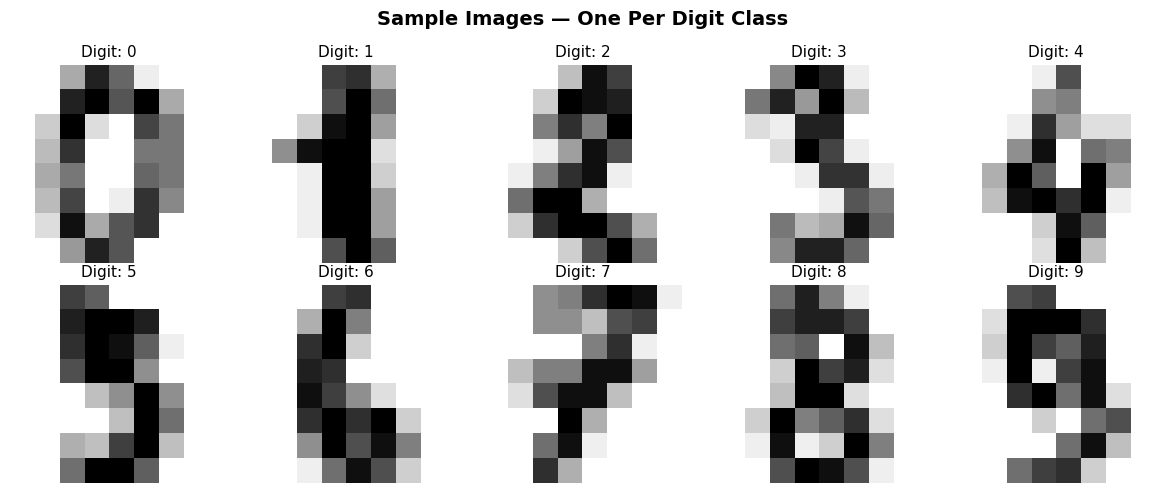

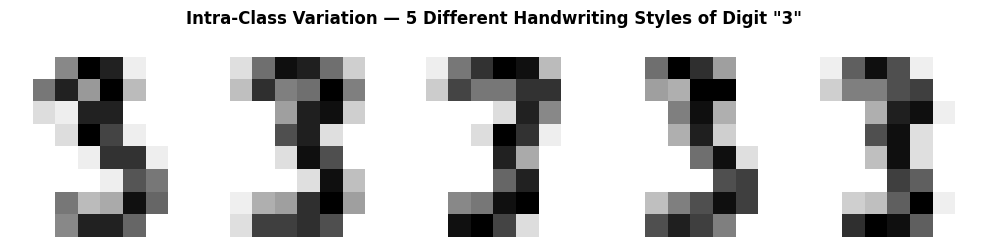

In [3]:
# Display one sample image per digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images — One Per Digit Class', fontsize=14, fontweight='bold')

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(images[idx], cmap='gray_r')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show intra-class variation — 5 examples of the same digit
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
fig.suptitle('Intra-Class Variation — 5 Different Handwriting Styles of Digit "3"',
             fontsize=12, fontweight='bold')
for ax, idx in zip(axes, np.where(y == 3)[0][:5]):
    ax.imshow(images[idx], cmap='gray_r')
    ax.axis('off')
plt.tight_layout()
plt.show()


**Q1.** Why is clustering more difficult than classification for this dataset?  
*(Think about what information each approach has access to during training.)*


**A1.** *(Write your answer here)*

...


**Q2.** Looking at the sample images and the intra-class variation, which pairs of digits do you expect a clustering algorithm to confuse most — and why?


**A2.** *(Write your answer here)*

...


---
## Part B — k-Means Clustering

> **Goal:** Apply k-Means and understand what it learns — and where its geometric assumptions break down.

📖 [K-Means — StatQuest (Video)](https://www.youtube.com/watch?v=4b5d3muPQmA)  
📖 [Interactive K-Means Visualiser](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

**Preprocessing note:** Before clustering, we standardise features (zero mean, unit variance) and apply PCA to retain 90% of the variance. This is standard practice — raw 64D pixel space has many near-zero variance dimensions that add distance noise without contributing signal. PCA removes them and produces a cleaner space for clustering.

**Key Concept — How k-Means Works:**
1. Initialise K centroids using k-means++ (smart placement to avoid bad starts)
2. **Assignment:** Each point is assigned to its nearest centroid by Euclidean distance
3. **Update:** Each centroid moves to the mean of its assigned points
4. Repeat until convergence

K-Means minimises **inertia** — total within-cluster squared distance:
$$\text{Inertia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**The fundamental limitation:** k-Means implicitly assumes every cluster is **spherical** (equal variance in all directions) and of roughly equal size. It draws straight perpendicular Voronoi boundaries between centroids — it has no mechanism to fit elongated, rotated, or differently-scaled clusters. Digit clusters in PCA space are rarely spherical, so k-Means will misassign points near boundaries.


In [4]:
# Preprocessing: standardise then PCA (retain 90% variance)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca    = PCA(n_components=0.90, random_state=42)   # keep enough components for 90% variance
X_pca  = pca.fit_transform(X_scaled)
n_comp = X_pca.shape[1]

# Also keep 2D projection for all visualisations
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)

print(f'After PCA: {n_features}D → {n_comp}D  (retaining 90% variance)')
print(f'This is the space we cluster in throughout the assignment.')


After PCA: 64D → 31D  (retaining 90% variance)
This is the space we cluster in throughout the assignment.


In [5]:
# Apply K-Means with K=10
kmeans    = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_pca)

ari_km = adjusted_rand_score(y, km_labels)
nmi_km = normalized_mutual_info_score(y, km_labels)
sil_km = silhouette_score(X_pca, km_labels, sample_size=500, random_state=42)

print(f'K-Means converged in {kmeans.n_iter_} iterations')
print(f'  ARI        : {ari_km:.4f}')
print(f'  NMI        : {nmi_km:.4f}')
print(f'  Silhouette : {sil_km:.4f}')

unique_cl, counts_cl = np.unique(km_labels, return_counts=True)
print('\nCluster sizes:')
for cl, cnt in zip(unique_cl, counts_cl):
    print(f'  Cluster {cl}: {cnt} samples')


K-Means converged in 37 iterations
  ARI        : 0.4625
  NMI        : 0.6219
  Silhouette : 0.1750

Cluster sizes:
  Cluster 0: 178 samples
  Cluster 1: 316 samples
  Cluster 2: 142 samples
  Cluster 3: 180 samples
  Cluster 4: 160 samples
  Cluster 5: 181 samples
  Cluster 6: 418 samples
  Cluster 7: 29 samples
  Cluster 8: 81 samples
  Cluster 9: 112 samples


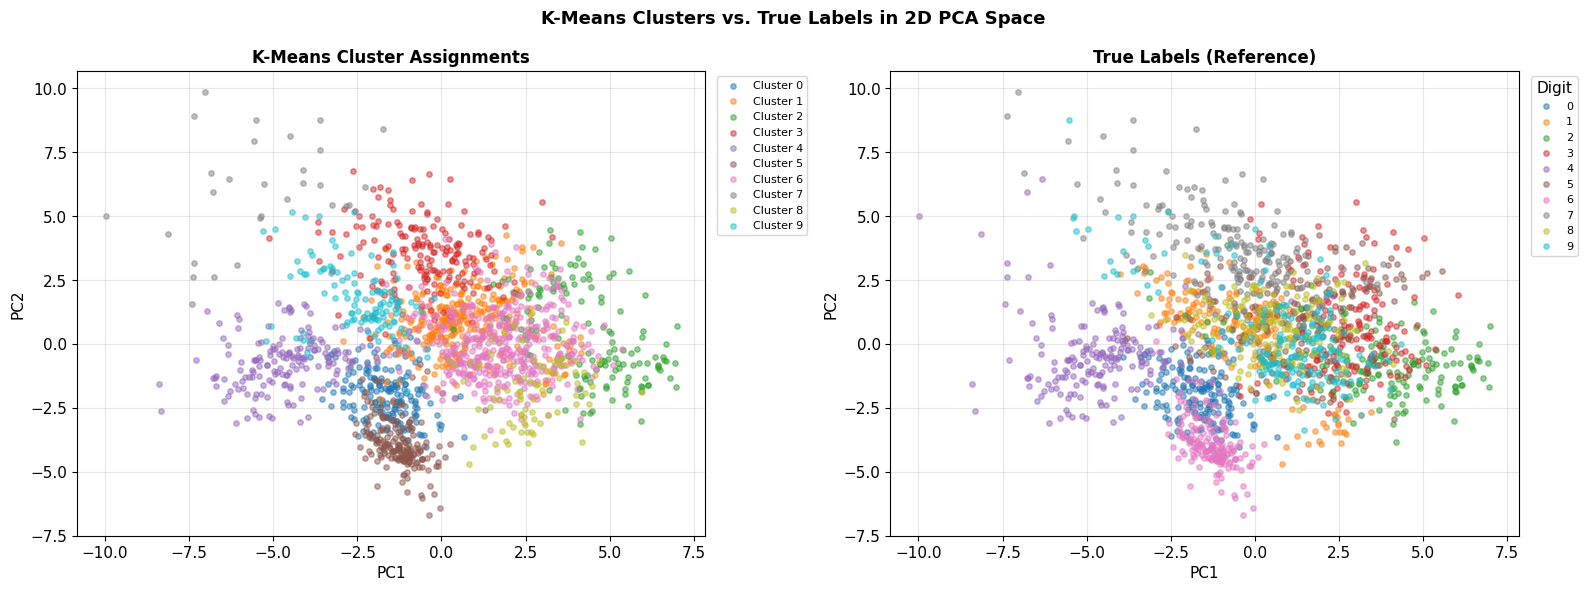

In [6]:
# Side-by-side: K-Means assignments vs True labels in 2D PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(10):
    mask = km_labels == cl
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    label=f'Cluster {cl}', alpha=0.5, s=15, color=cmap10(cl))
axes[0].set_title('K-Means Cluster Assignments', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for digit in range(10):
    mask = y == digit
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    label=str(digit), alpha=0.5, s=15, color=cmap10(digit))
axes[1].set_title('True Labels (Reference)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='Digit', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clusters vs. True Labels in 2D PCA Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


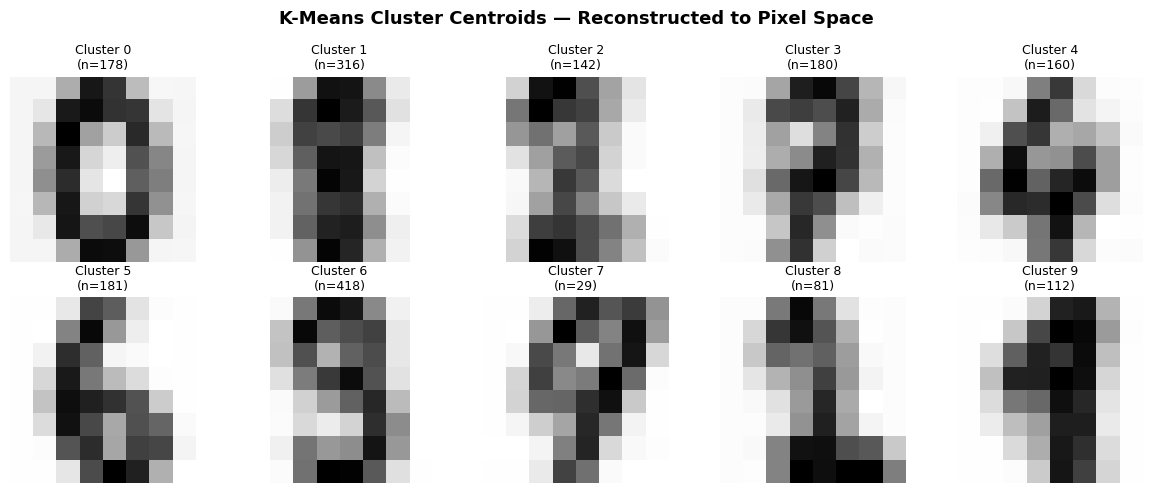

In [7]:
# Visualise cluster centroids reconstructed back to pixel space
centers_pixel = scaler.inverse_transform(
    pca.inverse_transform(kmeans.cluster_centers_)
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('K-Means Cluster Centroids — Reconstructed to Pixel Space',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(centers_pixel[i].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Cluster {i}\n(n={counts_cl[i]})', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


**Q3.** Why do cluster centroids appear blurry when reconstructed to pixel space?  
*(What mathematical operation produced the centroid? What happens when you average many different handwriting styles?)*


**A3.** *(Write your answer here)*

...


**Q4.** K-Means assumes all clusters are spherical and equally sized. Looking at the 2D PCA scatter plot, does this assumption hold for digit clusters?  
Which cluster looks most non-spherical — and how does that explain k-Means errors there?


**A4.** *(Write your answer here)*

...


---
## Part C — Cluster Confusion Analysis

> **Goal:** Map cluster IDs to digit labels and measure precisely where k-Means makes mistakes.

📖 [Confusion Matrix Explained — Towards Data Science](https://towardsdatascience.com/understanding-confusion-matrix-a9ad42dcfd62/)

**Key Concept — The Label Alignment Problem:**  
K-Means assigns arbitrary cluster IDs (0–9) with no relationship to digit identity — cluster 7 might contain mostly 4s.  
We solve this with **majority voting**: assign each cluster the digit that appears most frequently within it, then compute accuracy and draw the confusion matrix.


In [8]:
def majority_vote_mapping(cluster_labels, true_labels, n_clusters=10):
    """Map each cluster to its most frequent true label."""
    mapping = {}
    for cl in range(n_clusters):
        mask = cluster_labels == cl
        if mask.sum() == 0:
            mapping[cl] = -1
            continue
        mapping[cl] = np.argmax(np.bincount(true_labels[mask], minlength=n_clusters))
    predicted = np.array([mapping[cl] for cl in cluster_labels])
    return predicted, mapping


km_predicted, cluster_map = majority_vote_mapping(km_labels, y)

print('Cluster → Digit Mapping (Majority Vote):')
for cl, digit in sorted(cluster_map.items()):
    mask   = km_labels == cl
    purity = (y[mask] == digit).mean() * 100
    print(f'  Cluster {cl:2d} → Digit {digit}   purity: {purity:.1f}%')

km_acc = (km_predicted == y).mean() * 100
print(f'\nOverall mapping accuracy: {km_acc:.1f}%')


Cluster → Digit Mapping (Majority Vote):
  Cluster  0 → Digit 0   purity: 99.4%
  Cluster  1 → Digit 1   purity: 30.4%
  Cluster  2 → Digit 2   purity: 51.4%
  Cluster  3 → Digit 7   purity: 84.4%
  Cluster  4 → Digit 4   purity: 98.1%
  Cluster  5 → Digit 6   purity: 96.7%
  Cluster  6 → Digit 3   purity: 36.1%
  Cluster  7 → Digit 7   purity: 58.6%
  Cluster  8 → Digit 2   purity: 64.2%
  Cluster  9 → Digit 1   purity: 51.8%

Overall mapping accuracy: 61.7%


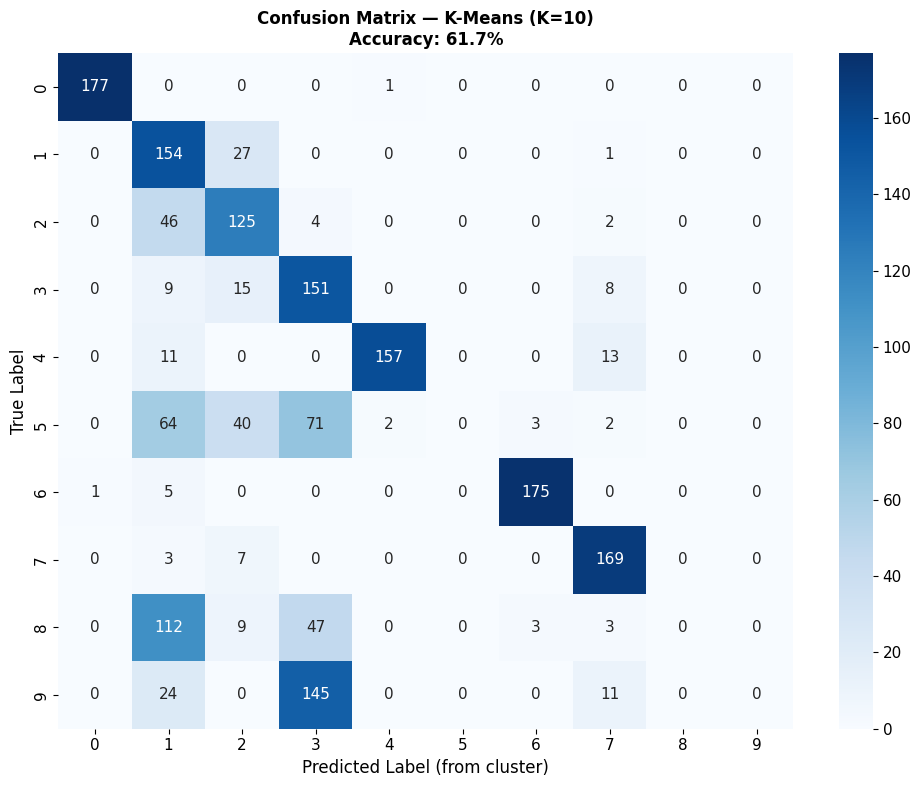

Most confused digit pairs (off-diagonal):
  True 9 predicted as 3: 145 times
  True 8 predicted as 1: 112 times
  True 5 predicted as 3: 71 times
  True 5 predicted as 1: 64 times


In [9]:
# Confusion matrix
cm_km = confusion_matrix(y, km_predicted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label (from cluster)', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — K-Means (K=10)\nAccuracy: {km_acc:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Most confused pairs
print('Most confused digit pairs (off-diagonal):')
off_diag = cm_km.copy()
np.fill_diagonal(off_diag, 0)
for _ in range(4):
    r, c = np.unravel_index(np.argmax(off_diag), off_diag.shape)
    if off_diag[r, c] > 0:
        print(f'  True {r} predicted as {c}: {off_diag[r, c]} times')
    off_diag[r, c] = 0


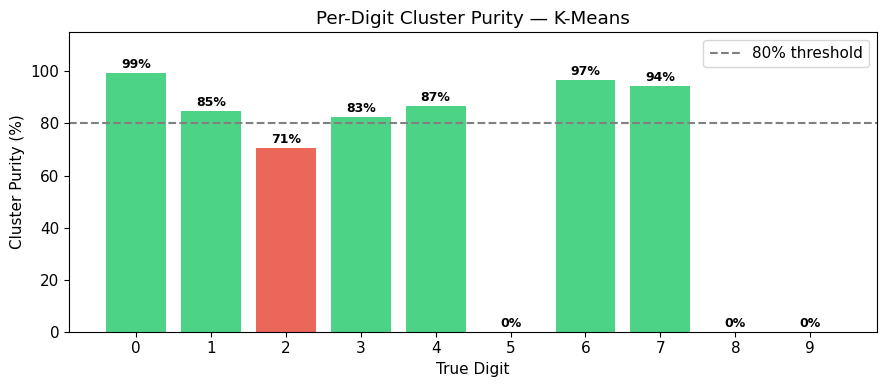

In [10]:
# Per-digit cluster purity bar chart
per_digit_purity = [
    (km_predicted[y == d] == d).mean() * 100
    for d in range(10)
]

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71' if p >= 80 else '#e74c3c' for p in per_digit_purity]
bars = ax.bar(range(10), per_digit_purity, color=bar_colors, alpha=0.85)
ax.axhline(80, color='gray', linestyle='--', label='80% threshold')
ax.set_xlabel('True Digit')
ax.set_ylabel('Cluster Purity (%)')
ax.set_title('Per-Digit Cluster Purity — K-Means')
ax.set_xticks(range(10))
ax.set_ylim(0, 115)
ax.legend()
for bar, val in zip(bars, per_digit_purity):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


**Q5.** Which digits appear most confused? Give a visual reason based on actual digit shapes.  
*(Support your answer with specific numbers from the confusion matrix.)*


**A5.** *(Write your answer here)*

...


---
## Part D — Evaluation Metrics

> **Goal:** Understand why ARI and NMI are the right metrics for clustering evaluation.

📖 [Evaluation Metrics for Clustering — Towards Data Science](https://towardsdatascience.com/evaluation-metrics-for-clustering-models-5dde821dd6cd/)  
📖 [Sklearn Clustering Evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)

**Key Concept — Why Raw Accuracy is Misleading:**  
Cluster IDs are arbitrary — if we compare cluster labels directly to digit labels without the majority-vote remapping, accuracy is meaningless. Even with majority voting, accuracy has a subtle flaw: if two clusters both map to the same digit (which can happen), some correctly-grouped points get counted as errors.  

ARI and NMI solve this by being **permutation-invariant** — they measure agreement at the level of pairs of points, not individual label values.

| Metric | Range | What it measures |
|---|---|---|
| **ARI** | −1 to 1 | Do pairs of points that belong together get clustered together? Adjusted for chance — a random clustering scores 0. |
| **NMI** | 0 to 1 | How much information does knowing the cluster assignment tell you about the true label? 1 = perfect, 0 = none. |
| **Silhouette** | −1 to 1 | Are points closer to their own cluster than to others? Does **not** use true labels — purely geometric. |


In [11]:
print('=' * 50)
print('  K-Means (K=10) — Full Evaluation')
print('=' * 50)
print(f'  ARI           : {ari_km:.4f}  (0=random, 1=perfect)')
print(f'  NMI           : {nmi_km:.4f}  (0=no info, 1=perfect)')
print(f'  Silhouette    : {sil_km:.4f}  (geometric quality only)')
print(f'  Mapped Acc.   : {km_acc:.1f}%  (after majority-vote remapping)')
print('=' * 50)

# Visualise: what does ARI=0 (random) actually look like as a baseline?
random_labels = np.random.randint(0, 10, size=n_samples)
ari_random = adjusted_rand_score(y, random_labels)
nmi_random = normalized_mutual_info_score(y, random_labels)
print(f'\nRandom clustering baseline:')
print(f'  ARI  : {ari_random:.4f}  (should be ≈ 0)')
print(f'  NMI  : {nmi_random:.4f}  (should be ≈ 0)')
print(f'\nK-Means is {ari_km / max(ari_random, 0.001):.0f}x better than random on ARI.')


  K-Means (K=10) — Full Evaluation
  ARI           : 0.4625  (0=random, 1=perfect)
  NMI           : 0.6219  (0=no info, 1=perfect)
  Silhouette    : 0.1750  (geometric quality only)
  Mapped Acc.   : 61.7%  (after majority-vote remapping)

Random clustering baseline:
  ARI  : 0.0005  (should be ≈ 0)
  NMI  : 0.0105  (should be ≈ 0)

K-Means is 463x better than random on ARI.


**Q6.** Clustering accuracy does not reach 100% even when K equals the true number of digit classes.  
Give two distinct reasons — one about the algorithm's assumptions, one about the nature of the data itself.


**A6.** *(Write your answer here)*

...


**Q7.** Why is ARI preferred over raw accuracy for evaluating clustering?  
*(What does 'adjusted for chance' mean? What score does a random clustering receive?)*


**A7.** *(Write your answer here)*

...


---
## Part E — Gaussian Mixture Model

> **Goal:** Move from hard spherical clusters to soft probabilistic elliptical ones, and see the improvement clearly.

📖 [GMM Explained — Towards Data Science](https://towardsdatascience.com/gaussian-mixture-model-clearly-explained-115010f7d4cf/)  
📖 [EM Algorithm — StatQuest (Video)](https://www.youtube.com/watch?v=REypj2sy_5U)  
📖 [GMM Covariance Types Demo — Sklearn](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_covariances.html)

**Key Concept — GMM vs. K-Means:**  
GMM models each cluster as a multivariate Gaussian with its own mean **μₖ** and covariance matrix **Σₖ**:

$$p(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

Two key advantages over k-Means:
1. **Shape flexibility** — the covariance matrix **Σₖ** lets each cluster be an ellipse of any size and orientation, not just a sphere
2. **Soft assignments** — instead of hard 0/1 membership, each point gets a probability over all clusters

---

### Understanding GMM Covariance Types

The covariance type is the most important hyperparameter in GMM. It controls what *shape* each cluster can take and how many parameters the model has to estimate.

**`spherical`** — each cluster has a single variance σₖ², applied equally in all directions.  
The cluster boundary is a perfect sphere (in 2D: a circle).  
This is mathematically equivalent to soft k-Means: same shape assumption, just with probabilistic assignments instead of hard ones.  
*Use when:* clusters are roughly equal-sized blobs and you have very few samples per cluster.

**`diag`** — each cluster has a separate variance per feature dimension, but no off-diagonal terms.  
The cluster boundary is an axis-aligned ellipse — it can stretch or compress along any individual feature axis, but cannot rotate.  
This assumes the features are **uncorrelated within each cluster**. After PCA (which decorrelates features), this is a reasonable assumption.  
*Use when:* features are uncorrelated (e.g. after PCA) and clusters have different spreads per dimension.

**`tied`** — all clusters share the **same** covariance matrix Σ, but have different means.  
Each cluster can be an ellipse of any shape and orientation — but all clusters must have the *same* shape and orientation.  
Far fewer parameters than `full`, which helps when data is limited.  
*Use when:* you believe all clusters have similar spread and orientation, just different positions.

**`full`** — each cluster has its **own** complete covariance matrix Σₖ.  
Each cluster can independently be any ellipse: any size, any shape, any rotation.  
Most flexible — but also most parameters to estimate. With too little data, this can overfit.  
*Use when:* clusters genuinely have different shapes and orientations and you have enough data to estimate them reliably.


**Why this matters for digits:** Digit clusters in PCA space are not spheres. A '1' forms a tall narrow cluster (high variance along one direction, low along others). A '0' forms a ring-like spread. `full` covariance can model each of these differently — `spherical` cannot.


In [12]:
# Fit all four covariance types and compare
cov_types   = ['full', 'diag', 'tied', 'spherical']
gmm_results = {}

print(f'{"Method":>16} {"ARI":>8} {"NMI":>8} {"Silhouette":>12}')
print('-' * 48)
print(f'{"K-Means":>16} {ari_km:>8.4f} {nmi_km:>8.4f} {sil_km:>12.4f}')

for cov_type in cov_types:
    gmm = GaussianMixture(n_components=10, covariance_type=cov_type,
                          n_init=5, random_state=42, max_iter=300)
    lbl = gmm.fit_predict(X_pca)
    ari_g = adjusted_rand_score(y, lbl)
    nmi_g = normalized_mutual_info_score(y, lbl)
    sil_g = silhouette_score(X_pca, lbl, sample_size=500, random_state=42)
    gmm_results[cov_type] = {
        'model': gmm, 'labels': lbl,
        'ARI': ari_g, 'NMI': nmi_g, 'Silhouette': sil_g
    }
    print(f'{"GMM "+cov_type:>16} {ari_g:>8.4f} {nmi_g:>8.4f} {sil_g:>12.4f}')


          Method      ARI      NMI   Silhouette
------------------------------------------------
         K-Means   0.4625   0.6219       0.1750
        GMM full   0.4034   0.6235       0.1293
        GMM diag   0.3504   0.5863       0.1121
        GMM tied   0.6020   0.7354       0.1669
   GMM spherical   0.5204   0.6423       0.1628


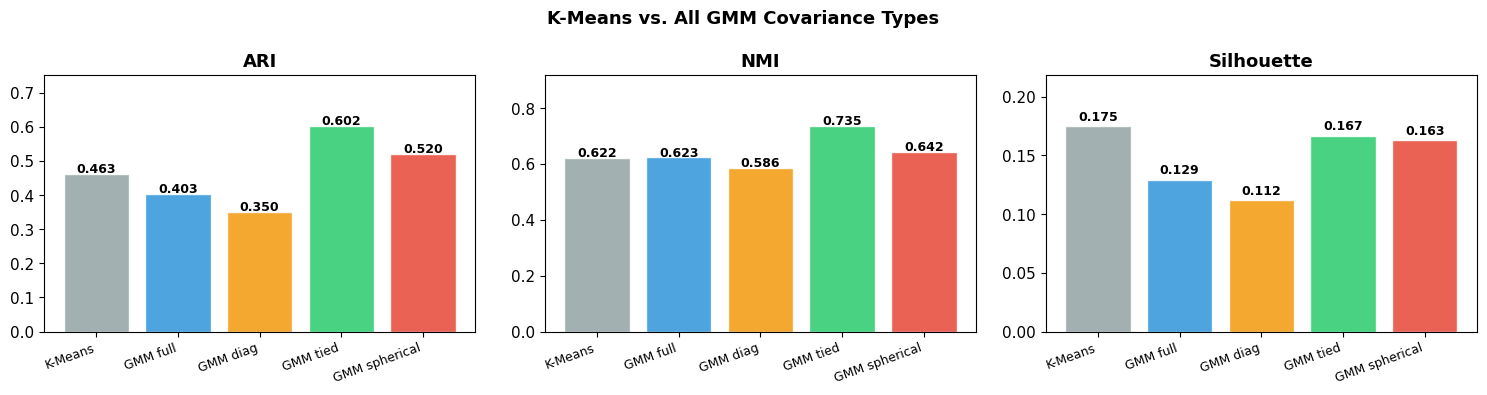

In [13]:
# Metric comparison bar chart
all_methods  = ['K-Means'] + ['GMM ' + c for c in cov_types]
all_aris     = [ari_km]   + [gmm_results[c]['ARI']        for c in cov_types]
all_nmis     = [nmi_km]   + [gmm_results[c]['NMI']        for c in cov_types]
all_sils     = [sil_km]   + [gmm_results[c]['Silhouette'] for c in cov_types]
bar_colors   = ['#95a5a6', '#3498db', '#f39c12', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, metric in zip(axes,
                             [all_aris, all_nmis, all_sils],
                             ['ARI', 'NMI', 'Silhouette']):
    bars = ax.bar(all_methods, vals, color=bar_colors, alpha=0.88, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(all_methods, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, min(1.0, max(vals) * 1.25))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('K-Means vs. All GMM Covariance Types', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


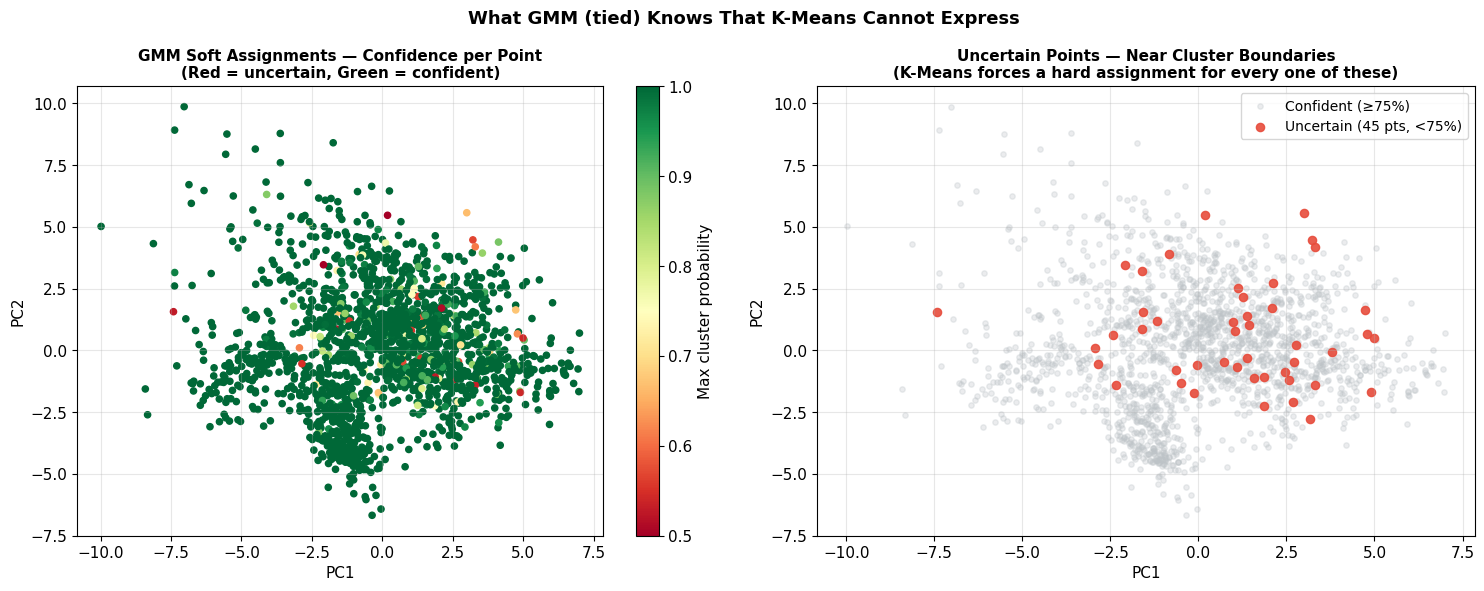

Best GMM covariance type: tied
Uncertain points (max prob < 0.75): 45
Very confident   (max prob > 0.99): 1591


In [14]:
# Soft probability visualisation — what GMM knows that K-Means does not
best_cov        = max(cov_types, key=lambda c: gmm_results[c]['ARI'])
best_gmm        = gmm_results[best_cov]
probs           = best_gmm['model'].predict_proba(X_pca)
max_probs       = probs.max(axis=1)
uncertain_mask  = max_probs < 0.75

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: confidence heatmap
sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                     c=max_probs, cmap='RdYlGn', s=20, vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=axes[0], label='Max cluster probability')
axes[0].set_title('GMM Soft Assignments — Confidence per Point\n'
                  '(Red = uncertain, Green = confident)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# Right: highlight uncertain points
axes[1].scatter(X_pca2[~uncertain_mask, 0], X_pca2[~uncertain_mask, 1],
                alpha=0.3, s=15, color='#bdc3c7', label='Confident (≥75%)')
axes[1].scatter(X_pca2[uncertain_mask, 0], X_pca2[uncertain_mask, 1],
                alpha=0.9, s=35, color='#e74c3c',
                label=f'Uncertain ({uncertain_mask.sum()} pts, <75%)')
axes[1].set_title('Uncertain Points — Near Cluster Boundaries\n'
                  '(K-Means forces a hard assignment for every one of these)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'What GMM ({best_cov}) Knows That K-Means Cannot Express',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best GMM covariance type: {best_cov}')
print(f'Uncertain points (max prob < 0.75): {uncertain_mask.sum()}')
print(f'Very confident   (max prob > 0.99): {(max_probs > 0.99).sum()}')


**Q8.** Why is k-Means a special case of GMM?  
*(State the exact conditions on covariance type and assignment rule that make the two equivalent.)*


**A8.** *(Write your answer here)*

...


**Q9.** The soft probability plot shows many "uncertain" points near cluster boundaries.  
In the DigitSort document scanning scenario, how would you use this uncertainty operationally?  
What would you do with a digit image that scores 0.55 for one cluster and 0.45 for another?


**A9.** *(Write your answer here)*

...


---
## Part F — Final Comparison

> **Goal:** Consolidate all results into a single table and compare confusion matrices side by side.


In [15]:
# Full summary table
summary = pd.DataFrame({
    'Method': [
        'K-Means (K=10)',
        'GMM spherical (K=10)',
        'GMM diag (K=10)',
        'GMM tied (K=10)',
        'GMM full (K=10)'
    ],
    'ARI': [
        round(ari_km, 4),
        round(gmm_results['spherical']['ARI'], 4),
        round(gmm_results['diag']['ARI'], 4),
        round(gmm_results['tied']['ARI'], 4),
        round(gmm_results['full']['ARI'], 4)
    ],
    'NMI': [
        round(nmi_km, 4),
        round(gmm_results['spherical']['NMI'], 4),
        round(gmm_results['diag']['NMI'], 4),
        round(gmm_results['tied']['NMI'], 4),
        round(gmm_results['full']['NMI'], 4)
    ],
    'Silhouette': [
        round(sil_km, 4),
        round(gmm_results['spherical']['Silhouette'], 4),
        round(gmm_results['diag']['Silhouette'], 4),
        round(gmm_results['tied']['Silhouette'], 4),
        round(gmm_results['full']['Silhouette'], 4)
    ],
    'Cluster shape': [
        'Sphere (hard)',
        'Sphere (soft)',
        'Axis-aligned ellipse',
        'Any ellipse (shared)',
        'Any ellipse (per cluster)'
    ]
})

print('=' * 85)
print('FINAL SUMMARY — DigitSort Clustering System')
print('=' * 85)
print(summary.to_string(index=False))
print('=' * 85)


FINAL SUMMARY — DigitSort Clustering System
              Method    ARI    NMI  Silhouette             Cluster shape
      K-Means (K=10) 0.4625 0.6219      0.1750             Sphere (hard)
GMM spherical (K=10) 0.5204 0.6423      0.1628             Sphere (soft)
     GMM diag (K=10) 0.3504 0.5863      0.1121      Axis-aligned ellipse
     GMM tied (K=10) 0.6020 0.7354      0.1669      Any ellipse (shared)
     GMM full (K=10) 0.4034 0.6235      0.1293 Any ellipse (per cluster)


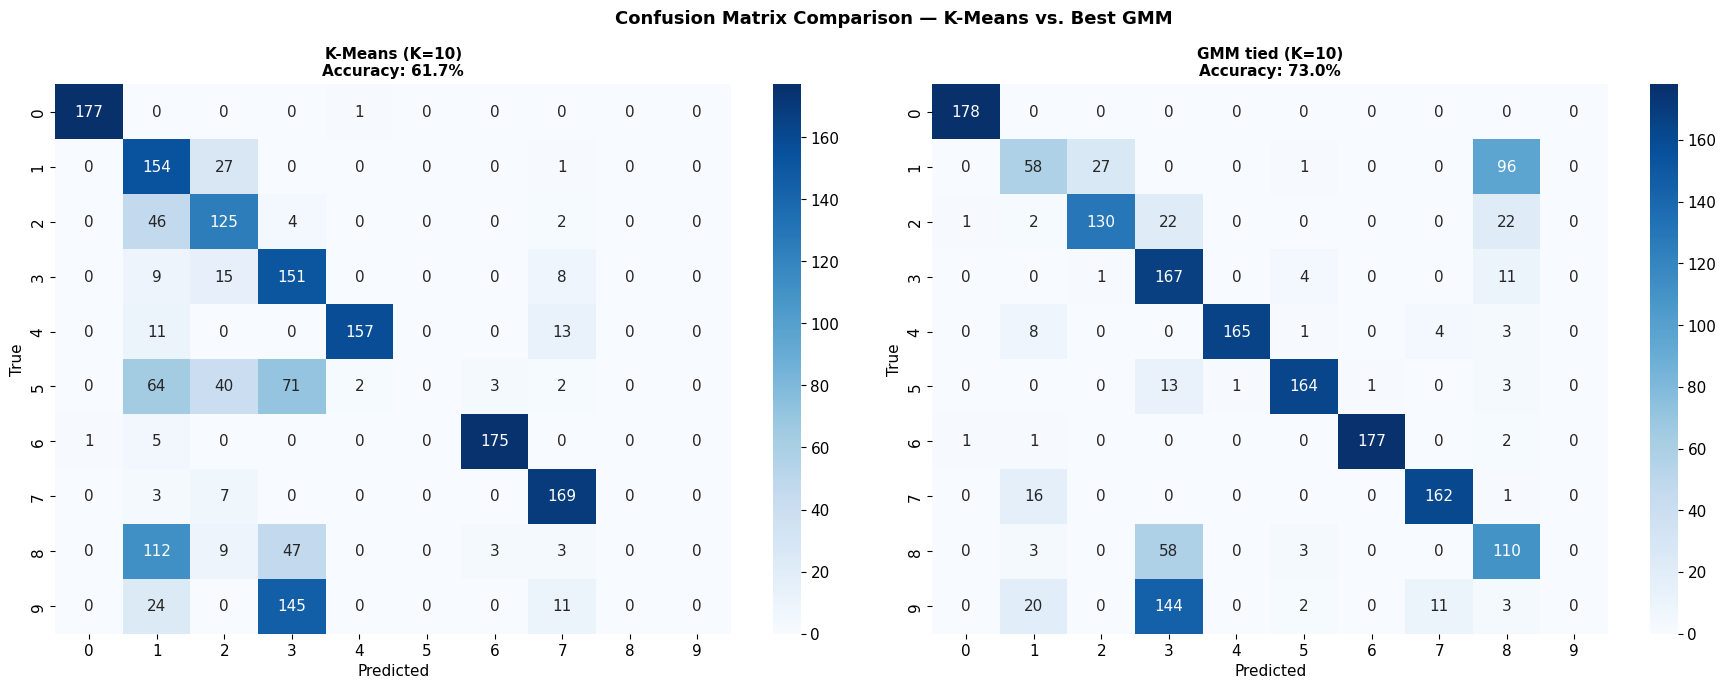

ARI improvement: K-Means 0.4625 → GMM tied 0.6020
Accuracy gain  : 61.7% → 73.0%


In [16]:
# Side-by-side confusion matrices: K-Means vs best GMM
gmm_predicted, _ = majority_vote_mapping(best_gmm['labels'], y)
gmm_acc = (gmm_predicted == y).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (pred, title, acc) in zip(axes, [
    (km_predicted,  'K-Means (K=10)',              km_acc),
    (gmm_predicted, f'GMM {best_cov} (K=10)',      gmm_acc)
]):
    cm_plot = confusion_matrix(y, pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10), ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nAccuracy: {acc:.1f}%', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — K-Means vs. Best GMM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'ARI improvement: K-Means {ari_km:.4f} → GMM {best_cov} {best_gmm["ARI"]:.4f}')
print(f'Accuracy gain  : {km_acc:.1f}% → {gmm_acc:.1f}%')


**Q11.** Comparing the two confusion matrices, which specific digit pairs does GMM improve on compared to K-Means?  
Can you connect those improvements to what covariance flexibility gives GMM?


**A11.** *(Write your answer here)*

...


---
## Final Reflection

Answer each in 3–5 sentences.


**Reflection 1 — Limitations of K-Means**

Based on your experiments, describe the core geometric limitations of k-Means on this dataset.  
Under what conditions would k-Means work well, and when does it fundamentally break down?


**Your answer:** ...


**Reflection 2 — Hard vs. Soft Clustering**

K-Means forces a hard assignment for every point. GMM exposes probabilistic uncertainty.  
In the DigitSort document scanning scenario, why is knowing *which* digits are uncertain operationally useful?  
What real-world decision would you make differently with that information?


**Your answer:** ...


**Reflection 3 — Why Clusters Don't Perfectly Match Labels**

Even the best GMM does not achieve ARI = 1.0.  
Give two distinct reasons why unsupervised clustering cannot perfectly recover ground-truth digit labels — even with a flexible model and PCA preprocessing.


**Your answer:** ...
